In [1]:
# This cell does not render in the docs because of the tag `remove-input`
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings("ignore")

# Custom Encoders

Glass box UMAP wraps a neural network around UMAP's loss. The choice of network, the *encoder*, controls what the model can learn about your data and what kinds of features it can attribute back to inputs. The library ships a strong default, and an encoder registry lets you plug in your own.

This guide is about that registry. It first walks through what the default encoder looks like and why it's structured the way it is. Then, it describes the registry contract: what your class must promise so glass box UMAP can use it. And finally, as a worked example, we register a custom encoder and run it on a dataset.

## The default encoder

The default encoder is `DeepPReLUNet`. It is intentionally a flat multi-layer perceptron (MLP), built from three kinds of layer:

* `nn.Linear(..., bias=False)`.
* `VmapPReLU`, a home-brewed equivalent of [PReLU](https://docs.pytorch.org/docs/2.11/generated/torch.nn.PReLU.html) that's compatible with an efficient calculation of the Jacobian via [vmap](https://docs.pytorch.org/tutorials/unstable/vmap_recipe.html).
* `LayerNormDetached`, which is a layer norm without an additive learned offset (bias term).

The combination is not arbitrary. Glass box UMAP's defining feature is *exact* per-feature attribution, and that property requires the encoder to be **piecewise linear** and **bias-free**. Linear layers without bias and PReLU activations together define a piecewise linear map. On any small neighborhood of the input space, the encoder behaves exactly like a single matrix multiplication, and that matrix is the encoder's Jacobian at that point. Multiplying by the input recovers an exact contribution from each feature to each embedding coordinate. Add a bias or use a non-piecewise-linear activation, and that property breaks.

Here is the actual class.

In [2]:
from glass_box_umap.parametric_umap.models import DeepPReLUNet

DeepPReLUNet(input_dims=(64,), n_components=2)

DeepPReLUNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (model): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=False)
    (1): VmapPReLU(num_parameters=1)
    (2): LayerNormDetached()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=False)
    (5): VmapPReLU(num_parameters=1)
    (6): LayerNormDetached()
    (7): Dropout(p=0.0, inplace=False)
    (8): Linear(in_features=128, out_features=128, bias=False)
    (9): VmapPReLU(num_parameters=1)
    (10): Dropout(p=0.0, inplace=False)
    (11): Linear(in_features=128, out_features=2, bias=False)
  )
)

A few things worth pointing out about this architecture:

* It is a flat MLP. The `Flatten` at the top means the encoder is structure-agnostic. Whatever shape the input has, it sees a single long vector.
* Width and depth are modest. Three hidden layers of 128 units is enough to learn a good 2D embedding for most datasets without becoming hard to train.
* Dropout defaults to 0. Glass box UMAP relies on a clean, deterministic forward pass for attribution. Dropout would inject noise into the Jacobian.

## Changing default encoder parameters

The default encoder has default parameters:

In [3]:
DeepPReLUNet?

Init signature:
DeepPReLUNet(
    input_dims: tuple[int, ...],
    n_components: int = 2,
    hidden_size: int = 128,
    n_hidden_layers: int = 3,
    dropout_rate: float = 0.0,
)
Docstring:      A network with PReLU activation and LayerNormDetached.
Init docstring: Initialize internal Module state, shared by both nn.Module and ScriptModule.
File:           ~/Software/arcadia/glass-box-umap/src/glass_box_umap/parametric_umap/models.py
Type:           type
Subclasses:     

These parameters can be modified using [GlassBoxUMAP](../autoapi/glass_box_umap/index.rst#glass_box_umap.GlassBoxUMAP)'s `encoder_kwargs` attribute:

In [4]:
from glass_box_umap import GlassBoxUMAP

# Let's make the hidden size 512.
reducer = GlassBoxUMAP(
    min_dist=0.1,
    n_neighbors=15,
    encoder_kwargs={"hidden_size": 512},
)

# I changed my mind, let's also have just 1 hidden layer
reducer.encoder_kwargs["n_hidden_layers"] = 1

# Scratch all that, I just want the defaults
reducer.encoder_kwargs = {}

The above changes all modify the encoder state. The choice only becomes hardened once `fit(...)` (or `fit_transform(...)`) is called.

## The registry contract

Any `nn.Module` can be plugged in via the encoder registry. The contract is small.

1. **Constructor signature.** Your class accepts `input_dims: tuple[int, ...]` and `n_components: int` as it's first two arguments. Any extra kwargs are fine. They get passed through `encoder_kwargs` when you instantiate `GlassBoxUMAP` (seen above).
2. **Forward signature.** `forward(x)` returns a tensor of shape `(batch, n_components)`. Glass box UMAP handles batching and the rest of the training loop.
3. **Decoration.** The class is registered with `@register_encoder("name")`. Once registered, you can instantiate it with `GlassBoxUMAP(encoder_name="your_encoder_name", encoder_kwargs={...})` exactly like a built-in.
4. **For exact attribution.** Every `Linear` and `Conv` layer is bias-free, and every activation is piecewise linear. `VmapPReLU` is provided.

The first three are required. The fourth is required only if you want `compute_contributions` to keep returning exact attributions. If you're willing to give that up, you can use any architecture you like.

## A worked example: a Maxout encoder

The default encoder is a sequence of `Linear` and `VmapPReLU` layers. PReLU is itself a piecewise-linear function: `PReLU(x) = max(αx, x)`, a two-way max with a tied negative-slope parameter. The whole network is a composition of two-way maxes.

[Maxout](https://arxiv.org/abs/1302.4389) generalizes that. Each Maxout unit takes a `k`-way max over `k` independent linear projections of its input. Because each piece is a separate linear function, a Maxout layer with `k` projections can represent any continuous convex piecewise-linear function with `k` pieces, while a PReLU layer of the same width is restricted to functions that are pointwise reflections of two affine pieces. With `k = 2` and a tied slope you essentially recover PReLU. With larger `k` you get genuinely more expressive layers per unit. (In practice this means Maxout layers can be narrower than PReLU layers for the same approximation capacity, at the cost of more parameters per unit.)

This architecture satisfies our constraints. A `k`-way max of bias-free linear projections is itself piecewise linear and bias-free. Exact attribution still works. At any input `x`, exactly one of the `k` projections is the active one, and the local Jacobian is just that projection's weight matrix.

Before implementing this custom encoder, let's first take a look at the existing registry:

In [5]:
from glass_box_umap.parametric_umap.registry import view_registry

view_registry()

{'default': glass_box_umap.parametric_umap.models.DeepPReLUNet,
 'default_conv': glass_box_umap.parametric_umap.models.ConvEncoder}

Glass box UMAP comes shipped with the above encoders. To register your own encoder, you just need to define it, and decorate it with `@register_encoder("your_encoder_name")`:

In [6]:
import math

from torch import Tensor, nn

from glass_box_umap.components import LayerNormDetached
from glass_box_umap.parametric_umap.registry import register_encoder


class MaxoutLayer(nn.Module):
    """One Maxout layer: ``k``-way max over independent bias-free linear projections."""

    def __init__(self, in_features: int, out_features: int, k: int) -> None:
        super().__init__()
        self.out_features = out_features
        self.k = k
        self.linear = nn.Linear(in_features, out_features * k, bias=False)

    def forward(self, x: Tensor) -> Tensor:
        z = self.linear(x).view(x.shape[0], self.out_features, self.k)
        return z.max(dim=-1).values


@register_encoder("maxout_mlp")
class MaxoutEncoder(nn.Module):
    """Bias-free, piecewise-linear encoder built from Maxout layers.

    Each hidden unit is a ``k``-way max over independent linear projections,
    which preserves exact attribution while giving each unit more expressive
    pieces than a PReLU activation does.
    """

    def __init__(
        self,
        input_dims: tuple[int, ...],
        n_components: int = 2,
        hidden_size: int = 128,
        n_hidden_layers: int = 3,
        k: int = 4,
    ) -> None:
        super().__init__()
        in_features = math.prod(input_dims)
        self.flatten = nn.Flatten()

        layers: list[nn.Module] = []
        prev = in_features
        for i in range(n_hidden_layers):
            layers.append(MaxoutLayer(prev, hidden_size, k))
            if i < n_hidden_layers - 1:
                layers.append(LayerNormDetached(hidden_size))
            prev = hidden_size
        layers.append(nn.Linear(hidden_size, n_components, bias=False))

        self.model = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        return self.model(self.flatten(x))

You can verify it's registered with another call to `view_registry`:

In [7]:
view_registry()

{'default': glass_box_umap.parametric_umap.models.DeepPReLUNet,
 'default_conv': glass_box_umap.parametric_umap.models.ConvEncoder,
 'maxout_mlp': __main__.MaxoutEncoder}

## Running it on the digits dataset

The sklearn `digits` dataset is 8x8 grayscale images of handwritten digits, flattened here into 64-dim tabular vectors.

We hand the registered encoder to `GlassBoxUMAP` by name. We tailor the `encoder_kwargs` so that the model parameter count roughly matches the default encoder.

In [8]:
import numpy as np
import torch
from sklearn.datasets import load_digits

from glass_box_umap import GlassBoxUMAP

digits = load_digits()
X = torch.from_numpy(digits.data.astype(np.float32))
y = digits.target.astype(int)

print(f"X shape: {tuple(X.shape)}, dtype={X.dtype}")
print(f"y shape: {y.shape}, classes={np.unique(y)}")


X shape: (1797, 64), dtype=torch.float32
y shape: (1797,), classes=[0 1 2 3 4 5 6 7 8 9]


In [9]:
reducer_default = GlassBoxUMAP(
    random_state=42,
    quiet=True,
)

reducer_default.fit(X)
embed_default = reducer_default.transform(X)

In [10]:
reducer_maxout = GlassBoxUMAP(
    encoder_name="maxout_mlp",
    encoder_kwargs={"hidden_size": 96, "n_hidden_layers": 2, "k": 3},
    random_state=42,
    quiet=True,
)

reducer_maxout.fit(X)
embed_maxout = reducer_maxout.transform(X)

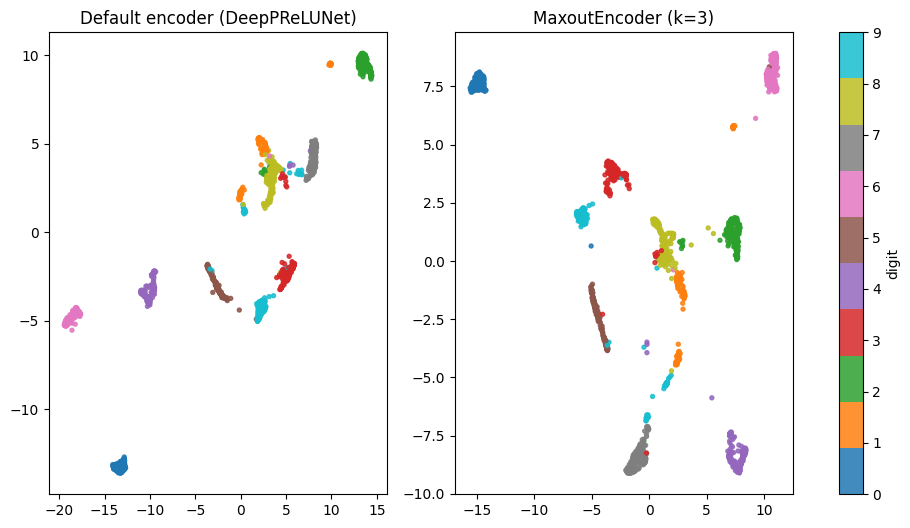

In [11]:
import matplotlib.pyplot as plt

CMAP = "tab10"

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, Z, title in zip(
    axes,
    [embed_default, embed_maxout],
    ["Default encoder (DeepPReLUNet)", "MaxoutEncoder (k=3)"],
):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap=CMAP, s=8, alpha=0.85)
    ax.set(title=title)
fig.colorbar(sc, ax=axes, label="digit", ticks=range(10))
plt.show()


The registry let us swap a meaningfully different architecture into glass box UMAP without touching the library, and the result is a sensible embedding.

## Exact attribution still works

The whole reason for the bias-free, piecewise-linear constraints is that `compute_contributions` returns a contribution from each input feature to each embedding coordinate, and those contributions sum exactly to the embedding. Maxout was designed to keep that property intact: a `k`-way max of bias-free linear functions is itself bias-free and piecewise linear. We can verify that the property still holds end to end.


In [12]:
contributions = reducer_maxout.compute_contributions(X)
n_samples, n_components = contributions.shape[:2]
reconstructed = contributions.reshape(n_samples, n_components, -1).sum(axis=2)

print(f"contributions shape: {contributions.shape}")
print(f"max |reconstructed - embedding|: {np.max(np.abs(reconstructed - embed_maxout)):.2e}")
print(f"matches embedding (atol 1e-4): {np.allclose(reconstructed, embed_maxout, atol=1e-4)}")


contributions shape: (1797, 2, 64)
max |reconstructed - embedding|: 3.81e-06
matches embedding (atol 1e-4): True


## Saving/Loading

Models built on a custom encoder and then saved to disk need a small extra step at load time. Glass box UMAP checkpoints store the encoder by *name*, not by class. When you call `load`, the library looks the name up, rebuilds an encoder of the same architecture, and then reattaches the saved weights. If your encoder's name does not appear in `view_registry()` at the moment `load` runs, the lookup fails with `ValueError: Encoder 'your_encoder_name' not found`.

The fix is to make sure your `@register_encoder(...)` decorator has executed before you call `load`. In practice that means putting your encoder in an importable module and importing it on the loading side:

```python
# Either import it
import my_project.encoders

# Or define and register it
@register_encoder("your_encoder_name")
class YourEncoder(nn.Module):
    ...

reducer = GlassBoxUMAP.load("model.pt")
```

## Conclusion

Custom encoders can be registered using a one-line decorator, so long as its constructor takes `input_dims` and `n_componens` as its first two arguments, and `forward` returns a tensor of shape `(batch, n_components)`. If you create a custom encoder, always verify it preserves exact feature attributions.

:::{warn}
Please keep in mind that the kNN graph is upstream of the encoder. Custom architectures change how the model represents inputs, not which inputs are considered neighbors. If you need a different notion of similarity, consider supplying a precomputed nearest-neighbors graph.
:::